# HOUSE PRICE PREDECTION

**PROBLEM STATEMENT:** Predict the price of house based on it's features.

**Dataset:** House Price Predection Dataset downloaded from keggle. (Path : https://www.kaggle.com/datasets/zafarali27/house-price-prediction-dataset)

This project contains:
1. EDA
2. Cleaning & Preprocessing
3. Train 3 ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyperparameter tuning
7. Predict on unseen data

### 1. Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

### 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/House Price Prediction Dataset.csv')
print(df.shape)
df.sample(5)

(2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
510,511,1428,1,1,1,1939,Downtown,Good,Yes,202842
799,800,4262,3,3,2,1998,Suburban,Excellent,Yes,163394
1266,1267,4951,2,2,3,1989,Rural,Fair,No,196474
928,929,1451,3,3,3,1906,Urban,Poor,No,843387
1276,1277,2074,2,2,2,1988,Downtown,Good,No,108122


### 3. Exploratory Data Analysis(EDA)
Objective : To understand data before making any changes - check size, type, missing values and relationship between features.

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


Here we can see that there are 10 columns: 7 - Numerical Columns ; 3 - Categorical Columns

In [88]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [89]:
df.describe(include='object')

,Location,Condition,Garage
count,2000,2000,2000
unique,4,4,2
top,Downtown,Fair,No
freq,558,521,1038


In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
# Checking for Missing Value
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

There are no missing value in the dataset.

In [92]:
# Dropping the Irrelevant Column (Id)
df = df.drop('Id', axis=1)

SPEARMAN'S CORRELATION: 
Price        1.000000
Floors       0.055928
YearBuilt    0.004720
Area         0.001660
Bedrooms    -0.004044
Bathrooms   -0.015218
Name: Price, dtype: float64


KENDALL'S CORRELATION: 
Price        1.000000
Floors       0.043229
YearBuilt    0.003272
Area         0.001522
Bedrooms    -0.002935
Bathrooms   -0.011391
Name: Price, dtype: float64


PEARSON'S CORRELATION: 
Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Name: Price, dtype: float64




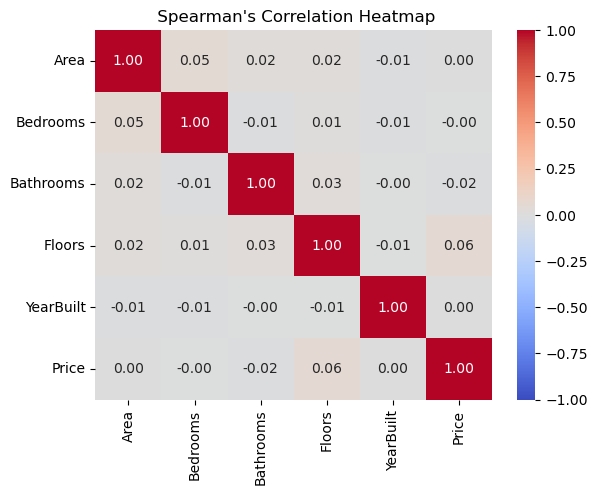

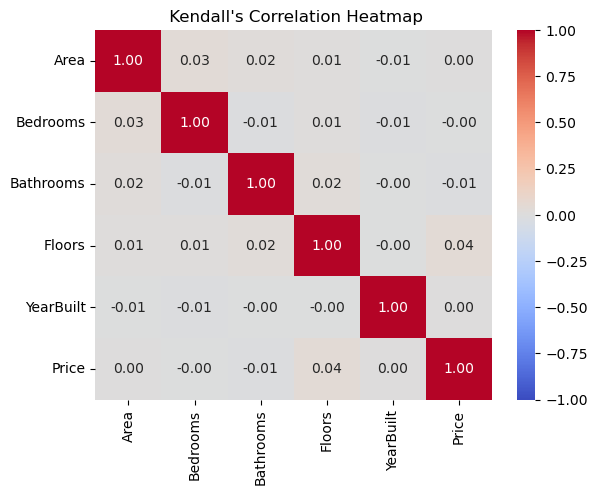

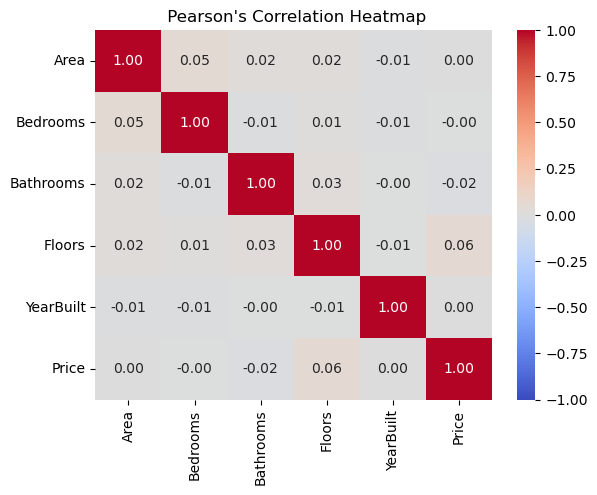

In [93]:
# Correlation heatmap (correlated features with price)
corr1 = df.select_dtypes(exclude='object').corr(method='spearman')
corr2 = df.select_dtypes(exclude='object').corr(method='kendall')
corr3 = df.select_dtypes(exclude='object').corr(method='pearson')
print(f"SPEARMAN'S CORRELATION: \n{corr1['Price'].sort_values(ascending=False)}\n\n")
print(f"KENDALL'S CORRELATION: \n{corr2['Price'].sort_values(ascending=False)}\n\n")
print(f"PEARSON'S CORRELATION: \n{corr3['Price'].sort_values(ascending=False)}\n\n")
sns.heatmap(corr1, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title(" Spearman's Correlation Heatmap")
plt.show()
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title(" Kendall's Correlation Heatmap")
plt.show()
sns.heatmap(corr3, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title(" Pearson's Correlation Heatmap")
plt.show()

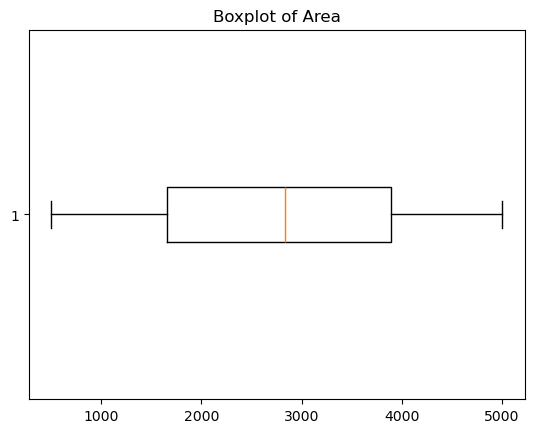

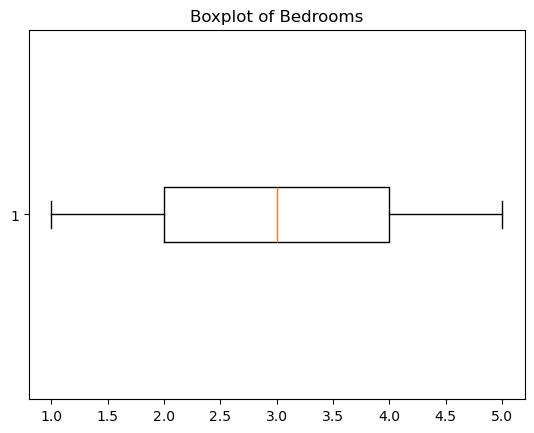

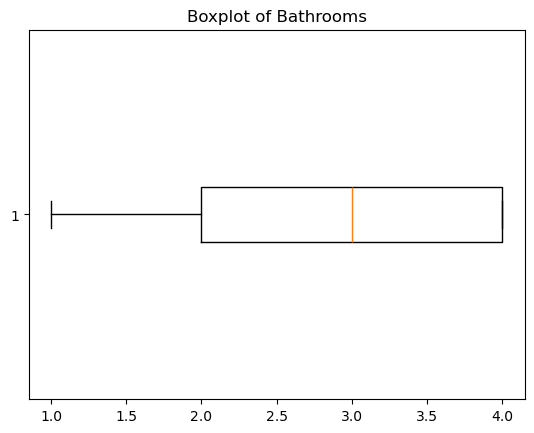

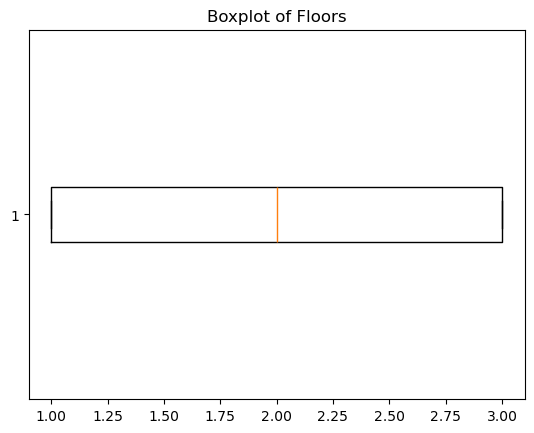

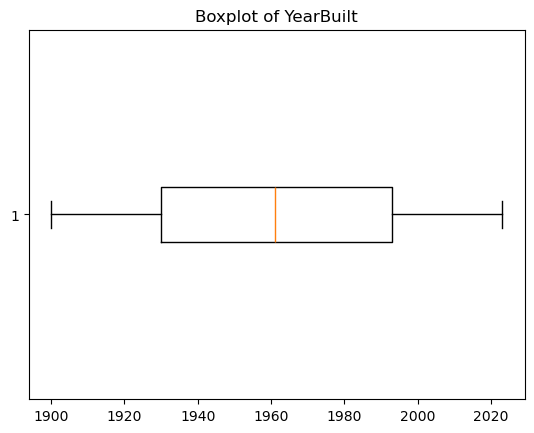

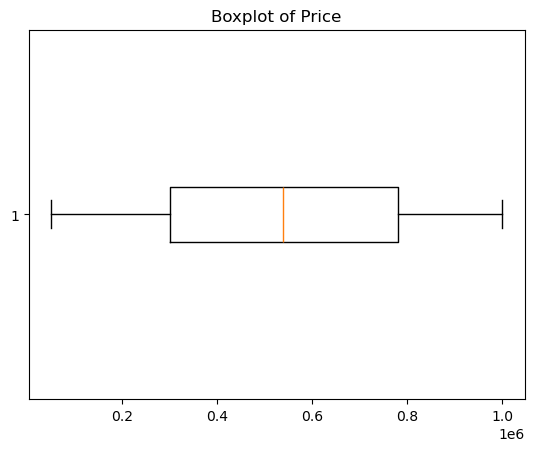

In [94]:
num_cols = df.select_dtypes(exclude='object').columns
num_cols
for cols in num_cols:
    plt.boxplot(x=df[cols], vert=False)
    plt.title(f"Boxplot of {cols}")
    plt.show()

EDA Takeaways:
- No missing values so, no imputation is needed.
- No columns have strong correlation with target column (price).
- No outliers on any columns


### 4. Data Cleaning and Preprocessing

In [95]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Here i want to the age of the house instead of the year it was built. So, i will convert `YearBuilt` to `Age`.

In [96]:
df['Age'] = 2026-df[['YearBuilt']]
df = df.drop('YearBuilt',axis=1)
df.head()

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price,Age
0,1360,5,4,3,Downtown,Excellent,No,149919,56
1,4272,5,4,3,Downtown,Excellent,No,424998,68
2,3592,2,2,3,Downtown,Good,No,266746,88
3,966,4,2,2,Suburban,Fair,Yes,244020,124
4,4926,1,4,2,Downtown,Fair,Yes,636056,51


Here i can see the 

In [97]:
df.Price.skew(),df.Area.skew()
# here we can see both columns have skewness ~ 0, so we don't need to take the log value for these columns

(np.float64(-0.06435063707629374), np.float64(-0.03855182209251573))

In [98]:
X = df.drop('Price',axis=1)
y = df['Price']

In [99]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   Location   2000 non-null   object
 5   Condition  2000 non-null   object
 6   Garage     2000 non-null   object
 7   Age        2000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 125.1+ KB


In [100]:
scaler = StandardScaler()
ohe = OneHotEncoder(drop='first')
scaling_columns = X.select_dtypes(exclude='object').columns
ohe_cols = X.select_dtypes(exclude=['int64','float64']).columns

In [101]:
scaling_columns,ohe_cols

(Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age'], dtype='object'),
 Index(['Location', 'Condition', 'Garage'], dtype='object'))

In [102]:
preprocessor = ColumnTransformer([
    ('StandardScaler',scaler,scaling_columns),
    ('OneHotEncoder',ohe,ohe_cols)
],remainder='passthrough')

In [103]:
X_train,X_test, y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 90 )

In [104]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1400, 8), (600, 8), (1400,), (600,))

In [105]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [106]:
X_test.shape,X_train.shape,y_train.shape,y_test.shape

((600, 12), (1400, 12), (1400,), (600,))

### 5. Train Models

In [107]:
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet':ElasticNet(),
    'RandomForestRegressor':RandomForestRegressor(),
    'Lasso':Lasso(),
    'DecisionTreeRegressor':DecisionTreeRegressor()
}

### 6. Compare Models Using Metrices

In [108]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    mae_test = mean_absolute_error(y_test,y_pred_test)
    mae_train = mean_absolute_error(y_train,y_pred_train)
    rmse_test = root_mean_squared_error(y_test,y_pred_test)
    rmse_train = root_mean_squared_error(y_train,y_pred_train)
    r2score_test = r2_score(y_test,y_pred_test)
    r2score_train = r2_score(y_train,y_pred_train)
    return mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train

In [109]:
res = []
for name,m in models.items():
    model = m
    model.fit(X_train,y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train = check_score(y_pred_test,y_test,y_pred_train,y_train)
    res.append({
            'Model':name,
            'MAE Test':mae_test,
            'MAE Train':mae_train,
            'RMSE Test':rmse_test,
            'RMSE Train':rmse_train,
            'R2 Score Test':r2score_test,
            'R2 Score Train':r2score_train
        })
    print('\n')
    print('='*30)
    print(f"Model Name : {name}")
    print('-'*30)
    print("FOR TESTING DATA:")
    print(f"Root Mean Squared Error : {rmse_test}")
    print(f" Mean Absolute Error : {mae_test}")
    print(f"R2 Score : {r2score_test}")
    print('-'*30)
    print("FOR TRAINING DATA:")
    print(f"Root Mean Squared Error : {rmse_train}")
    print(f" Mean Absolute Error : {mae_train}")
    print(f"R2 Score : {r2score_train}")
    print('='*30)
    print('\n')
    



Model Name : LinearRegression
------------------------------
FOR TESTING DATA:
Root Mean Squared Error : 274447.2600806605
 Mean Absolute Error : 237187.35121789703
R2 Score : -0.003919135160996623
------------------------------
FOR TRAINING DATA:
Root Mean Squared Error : 276022.1129802799
 Mean Absolute Error : 238874.82958911615
R2 Score : 0.009512589265103122




Model Name : ElasticNet
------------------------------
FOR TESTING DATA:
Root Mean Squared Error : 273973.9214496966
 Mean Absolute Error : 236986.14530012137
R2 Score : -0.00045920682296496373
------------------------------
FOR TRAINING DATA:
Root Mean Squared Error : 276412.79579927045
 Mean Absolute Error : 239258.79456768933
R2 Score : 0.006706725151277126




Model Name : RandomForestRegressor
------------------------------
FOR TESTING DATA:
Root Mean Squared Error : 282657.2656415415
 Mean Absolute Error : 242603.44721666668
R2 Score : -0.06488139689165084
------------------------------
FOR TRAINING DATA:
Root Mean

In [110]:
res_df = pd.DataFrame(res).sort_values(by='R2 Score Test', ascending=False)
res_df

,Model,MAE Test,MAE Train,RMSE Test,RMSE Train,R2 Score Test,R2 Score Train
1,ElasticNet,236986.145300,239258.794568,273973.921450,276412.795799,-0.000459,0.006707
3,Lasso,237187.057261,238874.826521,274446.877937,276022.113050,-0.003916,0.009513
0,LinearRegression,237187.351218,238874.829589,274447.260081,276022.112980,-0.003919,0.009513
2,RandomForestRegressor,242603.447217,91881.657264,282657.265642,107740.495382,-0.064881,0.849090
4,DecisionTreeRegressor,331121.498333,0.000000,400057.836923,0.000000,-1.133175,1.000000


<Axes: xlabel='Model'>

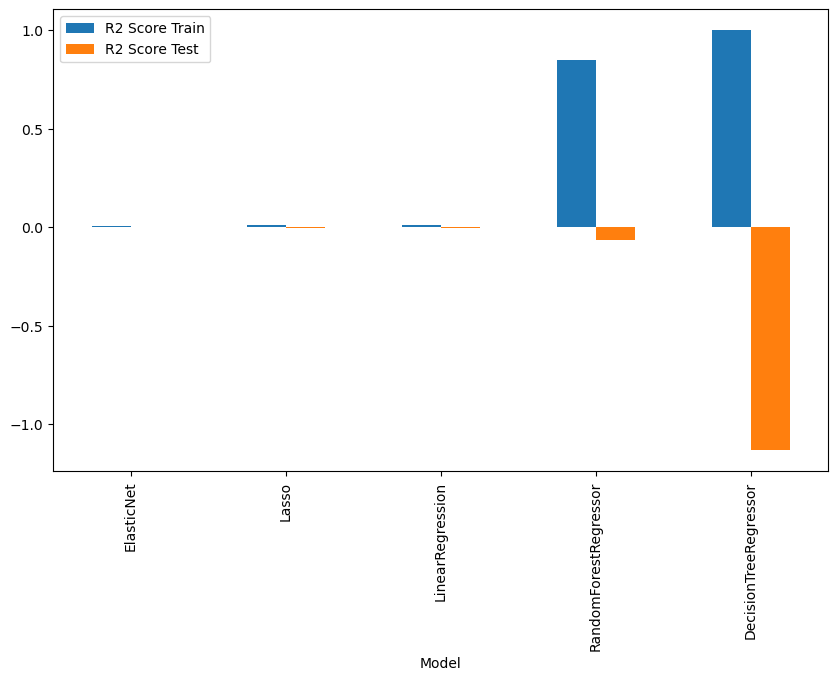

In [111]:
res_df.set_index(['Model'])[['R2 Score Train','R2 Score Test']].plot(kind='bar',figsize=(10,6))

### 7. Select and Justiify the Best Model

In [112]:
best_model = res_df.iloc[0][['Model']]
best_model

Model    ElasticNet
Name: 1, dtype: object

Here we can see ElasticNet performs better so we select it and tune it.

### 8. Tuning the Best Model (Grid Search CV)

In [113]:
mod = ElasticNet()
parameters = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
    'fit_intercept': [True, False],
    'max_iter': [1000, 2000, 5000, 10000],
    'tol': [1e-4, 1e-3, 1e-2],
    'selection': ['cyclic', 'random']
}

In [114]:
gs = GridSearchCV( mod, param_grid=parameters)

In [115]:
gs.fit(X_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.324e+13, tolerance: 8.758e+09
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.262e+13, tolerance: 8.583e+09
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.0001, 0.001, ...], 'fit_intercept': [True, False], 'l1_ratio': [0.0, 0.1, ...], 'max_iter': [1000, 2000, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [116]:
gs.best_params_

{'alpha': 1,
 'fit_intercept': True,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'selection': 'random',
 'tol': 0.0001}

In [117]:
elasticnet_model = ElasticNet(
    alpha=1,
    fit_intercept=True,
    l1_ratio=0.0,
    max_iter=1000,
    selection='random',
    tol=0.001
)

In [118]:
elasticnet_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.367e+13, tolerance: 1.077e+11
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


,alpha,1
,l1_ratio,0.0
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.001
,warm_start,False
,positive,False
,random_state,None
,selection,'random'


In [119]:
ytest_pred = elasticnet_model.predict(X_test)
ytrain_pred = elasticnet_model.predict(X_train)

In [120]:
maetest,maetrain,rmsetest,rmsetrain,r2scoretest,r2scoretrain = check_score(ytest_pred,y_test,ytrain_pred,y_train)

In [121]:
print("After HyperParameter Tuning:")
print('='*30)
print(f"Model Name : ElasticNet")
print('-'*30)
print("FOR TESTING DATA:")
print(f"Root Mean Squared Error : {rmsetest}")
print(f" Mean Absolute Error : {maetest}")
print(f"R2 Score : {r2scoretest}")
print('-'*30)
print("FOR TRAINING DATA:")
print(f"Root Mean Squared Error : {rmsetrain}")
print(f"Mean Absolute Error : {maetrain}")
print(f"R2 Score : {r2scoretrain}")
print('='*30)
print('\n')

After HyperParameter Tuning:
Model Name : ElasticNet
------------------------------
FOR TESTING DATA:
Root Mean Squared Error : 273950.6422245974
 Mean Absolute Error : 237049.31204646602
R2 Score : -0.0002891984842345874
------------------------------
FOR TRAINING DATA:
Root Mean Squared Error : 276636.8583144275
Mean Absolute Error : 239381.7094178141
R2 Score : 0.005095728864241256




### 9. Predict on Unseen Data

In [127]:
unseen_data = X.sample(5, random_state=30)
unseen_cleaned = preprocessor.transform(unseen_data)
unseen_pred = elasticnet_model.predict(unseen_cleaned)
pd.DataFrame(unseen_pred,columns=[['Price']])

,Price
0,548224.113735
1,540515.749386
2,544046.717383
3,558417.489481
4,536114.544598


## 9. Conclusion

- Trained and compared 5 models (LinearRegression,ElasticNet,RandomForestRegressor,Lasso,DecisionTreeRegressor) with hyperparameter tuning.
- The best-performing model was selected based on R2 Score.
- The selected model was used to predict on unseen samples successfully.
